In [1]:
import matplotlib.pyplot as plt
import numpy as np
import glob
import pandas as pd

In [13]:
headers = ['index', 'radius', 'vel_rms', 'crossing_time_vel', 'crossing_time_hp', 'press_height', 'e_int_spec', 'nabla', 'nabla_adiab', 'pressure', 'temperature', 'entropy', 'entropy_calc', 'e_kin', 'shell_mass', 'density', 'flux_enthalpy', 'flux_e_kin', 'flux_rad', 'flux_diff_scalar', 'vel_1_rms', 'vel_2_rms', 'vel_3_rms', 'vel_1', 'vel_2', 'vel_3', 'theta_1', 'u_phi_average_1', 'theta_2', 'u_phi_average_2', 'theta_3', 'u_phi_average_3', 'theta_4', 'u_phi_average_4', 'theta_5', 'u_phi_average_5', 'theta_6', 'u_phi_average_6', 'theta_7', 'u_phi_average_7', 'theta_8', 'u_phi_average_8', 'theta_9', 'u_phi_average_9', 'theta_10', 'u_phi_average_10', 'theta_11', 'u_phi_average_11', 'angular_momentum', 'scalar', 'flux_mass', 'nabla_mu_equiv', 'flux_heat_instant', 'flux_heat_init', 'flux_heat_ref_prof', 'flux_heat_ref_field', 'brunt_vaissala', 'temperature_std', 'temperature_skew', 'temperature_kurt', 'temperature_rms', 'density_std', 'density_skew', 'density_kurt', 'density_rms', 'temperature_fluct', 'temperature_up_fluct', 'temperature_down_fluct', 'vel_1_correlation', 'buoyancy_work', 'vel_1_std', 'vel_1_skew', 'vel_1_kurt', 'vel_1_rms', 'temperature_gradient', 'thermal_conductivity', 'strain_dev_1_1_squared', 'strain_dev_2_2_squared', 'strain_dev_3_3_squared', 'strain_dev_1_2_squared', 'strain_dev_1_3_squared', 'strain_dev_2_3_squared']
profile_headers = ['i','r_grid','P','E','rho','T','g_used','radc','y','Enuc','Vs']

In [3]:
r_tot = 70774597466.3827
r_bot = 0.4 * r_tot
r_top = 0.9 * r_tot
Nr = 570
Ntheta = 360
Nphi = 720
dr_grid = (r_top - r_bot) / Nr
r_env_init = 5.149819426617924E+10

In [4]:
PATTERN= "/z2/users/cj517/lscaledir_3D/r_min0.4_r_max0.9_from2d_v0_Om0/struc*2000*"
f1 = sorted(glob.glob(PATTERN))
PATTERN= "/z2/users/cj517/lscaledir_3D/r_min0.4_r_max0.9_from2d_v0_Om1/struc*2000*"
f2 = sorted(glob.glob(PATTERN))
PATTERN= "/z2/users/cj517/lscaledir_3D/r_min0.4_r_max0.9_from2d_v0_Om5/struc*2000*"
f3 = sorted(glob.glob(PATTERN))

In [5]:
f1,f2,f3

(['/z2/users/cj517/lscaledir_3D/r_min0.4_r_max0.9_from2d_v0_Om0/struc.cont000002000'],
 ['/z2/users/cj517/lscaledir_3D/r_min0.4_r_max0.9_from2d_v0_Om1/struc.cont000002000'],
 ['/z2/users/cj517/lscaledir_3D/r_min0.4_r_max0.9_from2d_v0_Om5/struc.cont000002000'])

In [7]:
df_OM0 = pd.DataFrame(np.genfromtxt(f1[0],skip_header=3),columns=headers)
df_OM0 = df_OM0.set_index('index')
df_OM1 = pd.DataFrame(np.genfromtxt(f2[0],skip_header=3),columns=headers)
df_OM1 = df_OM1.set_index('index')
df_OM5 = pd.DataFrame(np.genfromtxt(f3[0],skip_header=3),columns=headers)
df_OM5 = df_OM5.set_index('index')

In [10]:
PATTERN= "/z2/users/cj517/lscaledir_3D/r_min0.4_r_max0.9_from2d_v0_Om0/profile*"
prof = sorted(glob.glob(PATTERN))


'/z2/users/cj517/lscaledir_3D/r_min0.4_r_max0.9_from2d_v0_Om0/profile1d.dat'

In [15]:
profile_df = pd.DataFrame(np.genfromtxt(prof[0],skip_header=3), columns=profile_headers)
profile_df = profile_df.set_index('i')

In [16]:
profile_df

,r_grid,P,E,rho,T,g_used,radc,y,Enuc,Vs
i,,,,,,,,,,
1.0,2.830984e+10,2.451610e+15,1.027066e+15,3.619206,5.099795e+06,131992.461397,2.834495e+10,0.28,2.435748e-03,3.355938e+07
2.0,2.838005e+10,2.418371e+15,1.024430e+15,3.579531,5.086432e+06,131554.888497,2.841516e+10,0.28,2.371656e-03,3.351518e+07
3.0,2.845026e+10,2.385582e+15,1.021800e+15,3.540291,5.073103e+06,131118.462090,2.848537e+10,0.28,2.309251e-03,3.347104e+07
4.0,2.852048e+10,2.353237e+15,1.019178e+15,3.501482,5.059807e+06,130678.297954,2.855558e+10,0.28,2.248488e-03,3.342695e+07
5.0,2.859069e+10,2.321385e+15,1.016570e+15,3.463154,5.046583e+06,130241.875836,2.862580e+10,0.28,2.189370e-03,3.338304e+07
...,...,...,...,...,...,...,...,...,...,...
501.0,6.341629e+10,2.048772e+12,1.384361e+14,0.024794,6.295222e+05,32926.631177,6.345139e+10,0.28,1.602525e-13,1.172757e+07
502.0,6.348650e+10,1.992071e+12,1.370522e+14,0.024380,6.225856e+05,32855.290711,6.352161e+10,0.28,1.372067e-13,1.166197e+07
503.0,6.355671e+10,1.936427e+12,1.356710e+14,0.023969,6.156622e+05,32784.183275,6.359182e+10,0.28,1.172365e-13,1.159612e+07


(28309840000.0, 29000000000.0)

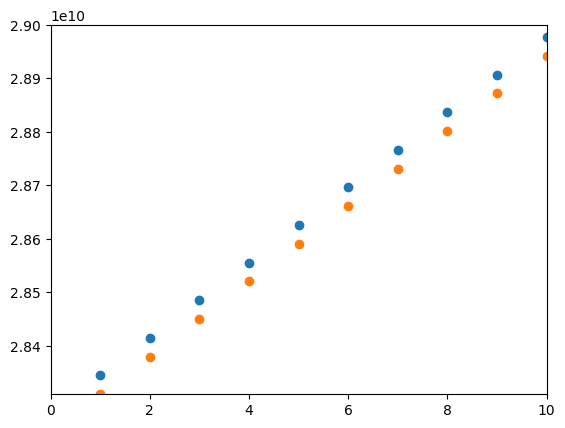

In [31]:
plt.scatter(df_OM0.index, df_OM0['radius'])
plt.scatter(profile_df.index, profile_df['r_grid'])

plt.xlim(0,10)
plt.ylim(2.830984e+10,2.9E10)

(63000000000.0, 64000000000.0)

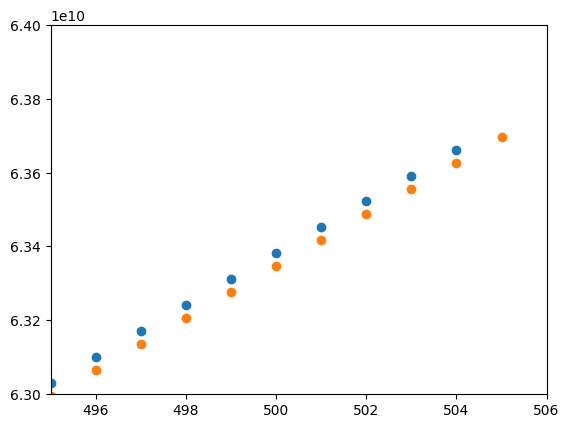

In [32]:
plt.scatter(df_OM0.index, df_OM0['radius'])
plt.scatter(profile_df.index, profile_df['r_grid'])

plt.xlim(495,506)
plt.ylim(6.3E10,6.4E10)

In [53]:
ls = []
g = []
for i,_ in enumerate(profile_df['r_grid']):
    if i == len(profile_df['r_grid']) - 1:
        break
    ls.append(np.mean([profile_df['r_grid'].values[i], profile_df['r_grid'].values[i+1]]))
    g.append(np.mean([profile_df['g_used'].values[i], profile_df['g_used'].values[i+1]]))

ls = np.array(ls)
g = np.array(g)

In [66]:
rotation = 13.51E-6
grad = ((df_OM5['nabla_adiab'] * df_OM5['thermal_conductivity']) ** -1) - 1
Rayleigh = 4 * df_OM5['pressure'] * (rotation ** 2) * grad / (df_OM5['density'] * g ** 2)
Super_w_Rayleigh5 = df_OM5['nabla'] - df_OM5['nabla_adiab'] + Rayleigh

rotation = 2.702E-6
grad = ((df_OM1['nabla_adiab'] * df_OM1['thermal_conductivity']) ** -1) - 1
Rayleigh = 4 * df_OM1['pressure'] * (rotation ** 2) * grad / (df_OM1['density'] * g ** 2)
Super_w_Rayleigh1 = df_OM1['nabla'] - df_OM1['nabla_adiab'] + Rayleigh

In [59]:
f1_name = r'$\Omega=0$'
f2_name = r'$\Omega=1$'
f3_name = r'$\Omega=5$'

In [65]:
df_OM0['super_adiab'] = df_OM0['nabla'] - df_OM0['nabla_adiab']
df_OM1['super_adiab'] = df_OM1['nabla'] - df_OM1['nabla_adiab']
df_OM5['super_adiab'] = df_OM5['nabla'] - df_OM5['nabla_adiab']

Text(0, 0.5, '$\\Omega=5$')

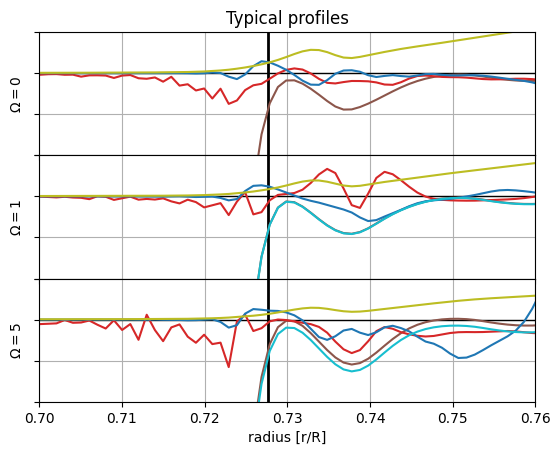

In [73]:
fig, (ax1, ax2, ax3) = plt.subplots(3, sharex=True)
ax1.set_xlim(0.7, 0.76)
ax1.set_ylim(-2,1)
ax2.set_xlim(0.7, 0.76)
ax2.set_ylim(-2,1)
ax3.set_xlim(0.7, 0.76)
ax3.set_ylim(-2,1)

ax1.axhline(0, color='k',linewidth=1)
ax2.axhline(0, color='k',linewidth=1)
ax3.axhline(0, color='k',linewidth=1)

# Schwarzschild Criterion
ax1.axvline(r_env_init / r_tot, color='k', label='Schw_1D',linewidth=2)
ax2.axvline(r_env_init / r_tot, color='k', label='Schw_1D',linewidth=2)
ax3.axvline(r_env_init / r_tot, color='k', label='Schw_1D',linewidth=2)

# # Mean Flux Depth
# ax1.axvline(- 0.0027906596902863255 + r_env_init / r_tot, color='tab:blue', label='Schw_1D',linewidth=2)
# ax2.axvline(- 0.0028516390372807718 + r_env_init / r_tot, color='tab:blue', label='Schw_1D',linewidth=2)
# ax3.axvline(- 0.0030592407497879223 + r_env_init / r_tot, color='tab:blue', label='Schw_1D',linewidth=2)

# # Mean Enthalpy Depth
# ax1.axvline(- 0.0018626018388730712 + r_env_init / r_tot, color='tab:red', label='Schw_1D',linewidth=2)
# ax2.axvline(- 0.00198720713513312 + r_env_init / r_tot, color='tab:red', label='Schw_1D',linewidth=2)
# ax3.axvline(- 0.0023629231105871335 + r_env_init / r_tot, color='tab:red', label='Schw_1D',linewidth=2)

# # Max Flux Depth
# ax1.axvline(- 0.012841429568499827 + r_env_init / r_tot, color='tab:blue', label='Schw_1D',linewidth=2, linestyle=':')
# ax2.axvline(- 0.012572467845509859 + r_env_init / r_tot, color='tab:blue', label='Schw_1D',linewidth=2, linestyle=':')
# ax3.axvline(- 0.013418904363545814 + r_env_init / r_tot, color='tab:blue', label='Schw_1D',linewidth=2, linestyle=':')

# # Max Enthalpy Depth
# ax1.axvline(- 0.012841429568499827 + r_env_init / r_tot, color='tab:red', label='Schw_1D',linewidth=2, linestyle=':')
# ax2.axvline(- 0.012572467845509859 + r_env_init / r_tot, color='tab:red', label='Schw_1D',linewidth=2, linestyle=':')
# ax3.axvline(- 0.013418904363545814 + r_env_init / r_tot, color='tab:red', label='Schw_1D',linewidth=2, linestyle=':')


vel_1_rms = df_OM0['vel_1_rms'].values.T[0]

ax1.plot(df_OM0['radius']/r_tot,df_OM0['super_adiab']/0.0005,c='tab:brown')
ax1.plot(df_OM0['radius']/r_tot,df_OM0['flux_enthalpy']/1E10,c='tab:red')
ax1.plot(df_OM0['radius']/r_tot,df_OM0['flux_e_kin']/5E7,c='tab:blue')
ax1.plot(df_OM0['radius']/r_tot,vel_1_rms/1E3,c='tab:olive')
ax1.set_yticklabels([])


vel_1_rms = df_OM1['vel_1_rms'].values.T[0]

ax2.plot(df_OM1['radius']/r_tot,df_OM1['super_adiab']/0.0005,c='tab:brown')
ax2.plot(df_OM1['radius']/r_tot,df_OM1['flux_enthalpy']/1E10,c='tab:red')
ax2.plot(df_OM1['radius']/r_tot,df_OM1['flux_e_kin']/5E7,c='tab:blue')
ax2.plot(df_OM1['radius']/r_tot,vel_1_rms/1E3,c='tab:olive')
ax2.plot(df_OM1['radius']/r_tot,Super_w_Rayleigh1/0.0005,c='tab:cyan')
ax2.set_yticklabels([])


vel_1_rms = df_OM5['vel_1_rms'].values.T[0]

ax3.plot(df_OM5['radius']/r_tot,df_OM5['super_adiab']/0.0005,c='tab:brown')
ax3.plot(df_OM5['radius']/r_tot,df_OM5['flux_enthalpy']/2E9,c='tab:red')
ax3.plot(df_OM5['radius']/r_tot,df_OM5['flux_e_kin']/1E7,c='tab:blue')
ax3.plot(df_OM5['radius']/r_tot,vel_1_rms/1E3,c='tab:olive')
ax3.plot(df_OM5['radius']/r_tot,Super_w_Rayleigh5/0.0005,c='tab:cyan')
ax3.set_yticklabels([])


fig.subplots_adjust(wspace=0, hspace=0)
ax3.set_xlabel('radius [r/R]')


ax1.grid()
ax2.grid()
ax3.grid()
    
ax1.set_title('Typical profiles')

ax1.set_ylabel(f1_name) #, rotation=45, labelpad=25)
ax2.set_ylabel(f2_name) #, rotation=45, labelpad=25)
ax3.set_ylabel(f3_name) #, rotation=45, labelpad=25)